##### LSTM Network - Prediction v9 (return-first multi-task model)\n\nThis notebook follows the same project workflow as the existing v7 example. The notebook remains intentionally thin: `StockPrediction`, `StockData`, `LongShortTermMemory`, `Plotter`, `train_LSTM_network` and `InferenceRunner` contain the implementation. v9 changes the target to next-session log returns and trains shared direction, expected-return and q10/q50/q90 heads.\n

In [2]:
# Install into this notebook's kernel, even when opened from examples/notebooks.
import subprocess
import sys
from pathlib import Path

current = Path.cwd().resolve()
repo_root = next((path for path in [current, *current.parents]
                  if (path / 'stock_prediction_class.py').is_file()), None)
if repo_root is None:
    raise RuntimeError('Open this notebook from the repository checkout.')
print('Installing dependencies into:', sys.executable)
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       '-r', str(repo_root / 'requirements.txt')])


Installing dependencies into: C:\Users\jordi\anaconda3\python.exe


0

In [3]:
# Copyright 2020-2026 Jordi Corbilla. All Rights Reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# ==============================================================================

import os
import warnings
import secrets
import pandas as pd
import argparse
import numpy as np
import pickle
import json
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / 'stock_prediction_class.py').exists():
        REPO_ROOT = candidate
        break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from stock_prediction_class import StockPrediction
from stock_prediction_lstm import LongShortTermMemory
from stock_prediction_numpy import StockData
from stock_prediction_plotter import Plotter
from stock_prediction_readme_generator import ReadmeGenerator
from stock_prediction_deep_learning import train_LSTM_network

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # or '3' to suppress all messages

# Suppress other warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow")
warnings.filterwarnings("ignore", message=".*np.object.*", category=FutureWarning)

import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import timedelta, datetime
from pandas.tseries.offsets import BDay

os.environ["PATH"] += os.pathsep + 'C:/Program Files (x86)/Graphviz2.38/bin/'

Ticker: ^FTSE
Start Date: 2017-01-01
Validation Date: 2024-10-16
Model Version: v9
Target: next-session log return
Test Run Folder: ^FTSE_v9_20260928_2db2e9444ce13970
End Date: 2026-09-28
mean: [0.57085496]
max 1.0
min 0.0
Std dev: [0.04857007]
plotting Data and Histogram


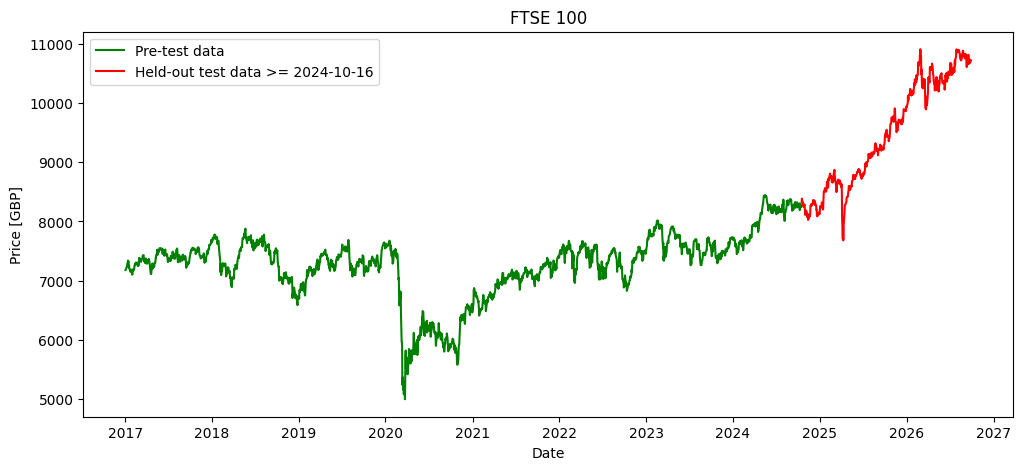

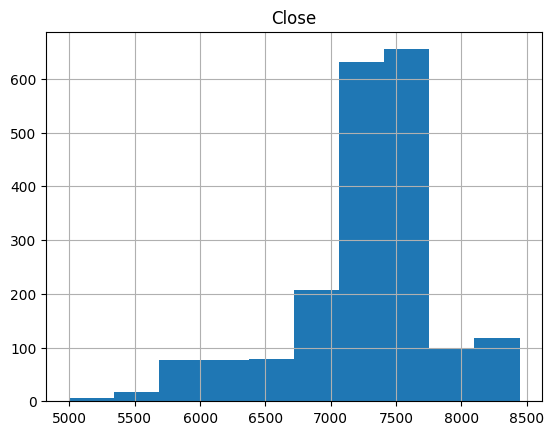

Model: "return_multitask_lstm_v9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ market_window (InputLayer)    │ (None, 60, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_lstm_1 (LSTM)          │ (None, 60, 128)           │          66,560 │ market_window[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dropout_1 (Dropout)    │ (None, 60, 128)           │               0 │ shared_lstm_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_lstm_2 (LSTM)          │ (None, 64)                │          49,408 │ shared_dropout_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dropout_2 (Dropout)    │ (None, 64)                │               0 │ shared_lstm_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ median_return (Dense)         │ (None, 1)                 │              65 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lower_distance (Dense)        │ (None, 1)                 │              65 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ upper_distance (Dense)        │ (None, 1)                 │              65 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ q10 (Subtract)                │ (None, 1)                 │               0 │ median_return[0][0],       │
│                               │                           │                 │ lower_distance[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ q90 (Add)                     │ (None, 1)                 │               0 │ median_return[0][0],       │
│                               │                           │                 │ upper_distance[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ direction (Dense)             │ (None, 1)                 │              65 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expected_return (Dense)       │ (None, 1)                 │              65 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ quantiles (Concatenate)       │ (None, 3)                 │               0 │ q10[0][0],                 │
│                               │                           │                 │ median_return[0][0],       │
│                               │                           │                 │ q90[0][0]                  │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 116,293 (454.27 KB)

 Trainable params: 116,293 (454.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
162/162 - 38s - 233ms/step - direction_accuracy: 0.5003 - direction_loss: 0.6964 - expected_return_MSE: 0.0122 - expected_return_loss: 0.0061 - loss: 0.1993 - quantiles_loss: 0.0381 - val_direction_accuracy: 0.5210 - val_direction_loss: 0.6943 - val_expected_return_MSE: 0.0019 - val_expected_return_loss: 9.6870e-04 - val_loss: 0.1826 - val_quantiles_loss: 0.0161 - learning_rate: 0.0010
Epoch 2/20
162/162 - 18s - 114ms/step - direction_accuracy: 0.5176 - direction_loss: 0.6931 - expected_return_MSE: 0.0065 - expected_return_loss: 0.0032 - loss: 0.1872 - quantiles_loss: 0.0213 - val_direction_accuracy: 0.5210 - val_direction_loss: 0.6939 - val_expected_return_MSE: 0.0023 - val_expected_return_loss: 0.0011 - val_loss: 0.1803 - val_quantiles_loss: 0.0113 - learning_rate: 0.0010
Epoch 3/20
162/162 - 22s - 137ms/step - direction_accuracy: 0.5343 - direction_loss: 0.6941 - expected_return_MSE: 0.0055 - expected_return_loss: 0.0027 - loss: 0.1853 - quantiles_loss: 0.0181 - val_direc

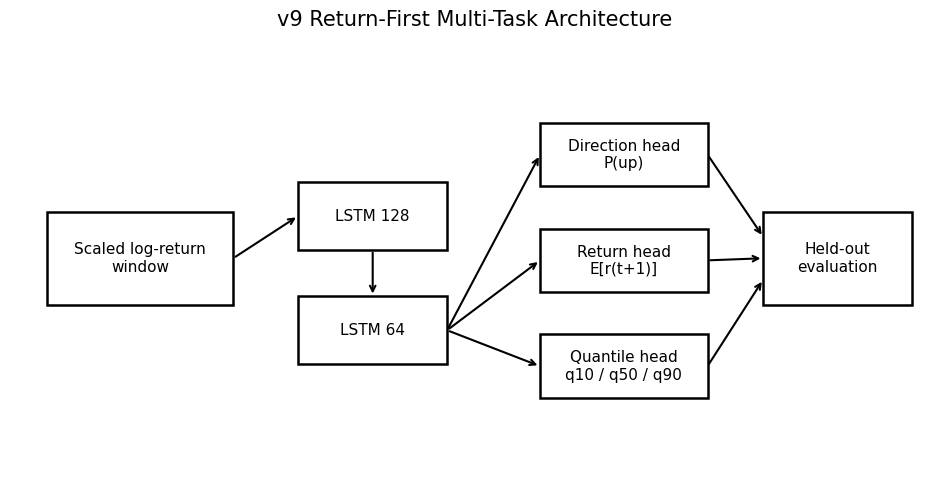

plotting loss


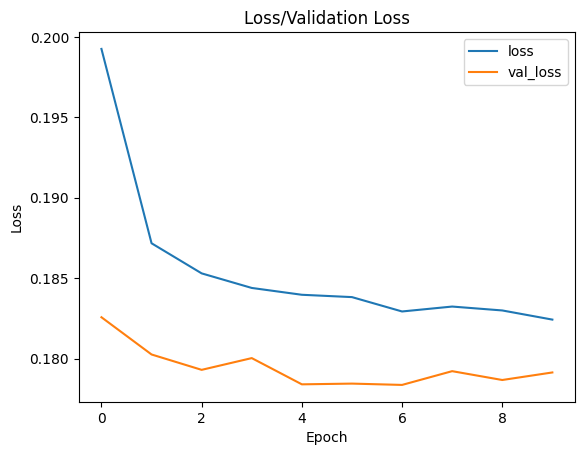

plotting MSE


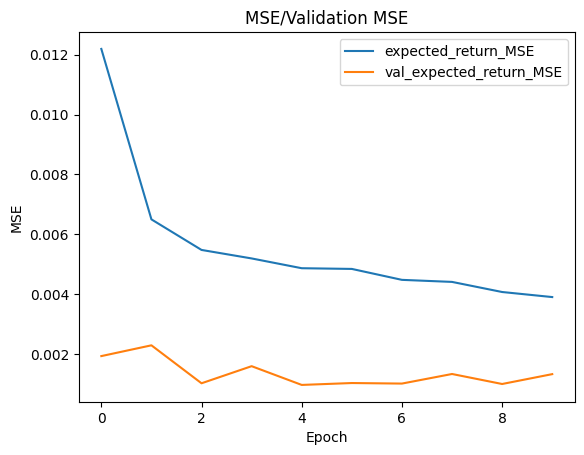

display the content of the model
16/16 - 1s - 41ms/step - direction_accuracy: 0.5558 - direction_loss: 0.6874 - expected_return_MSE: 0.0018 - expected_return_loss: 8.8992e-04 - loss: 0.1783 - quantiles_loss: 0.0112
direction_accuracy :  0.5557809472084045
direction_loss :  0.6874094605445862
expected_return_MSE :  0.0017932981718331575
expected_return_loss :  0.0008899237727746367
loss :  0.17834468185901642
quantiles_loss :  0.011216693557798862

plotting prediction results
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Return forecast metrics: {'return_rmse': 0.008544903795149845, 'return_mae': 0.006452477666548983, 'rmse_skill_vs_zero': -0.14347454959928396, 'direction_accuracy': 0.44421906693711966, 'direction_head_accuracy': 0.5557809330628803, 'delta_ic': -0.05387064407476348, 'q10_q90_coverage': 0.9310344827586207, 'q10_empirical_cdf': 0.010141987829614604, 'q50_empirical_cdf': 0.21095334685598377, 'q90_empirical_cdf': 0.9411764705882353, 'q10_q90_nominal_coverage': 0.8}
plotting predi

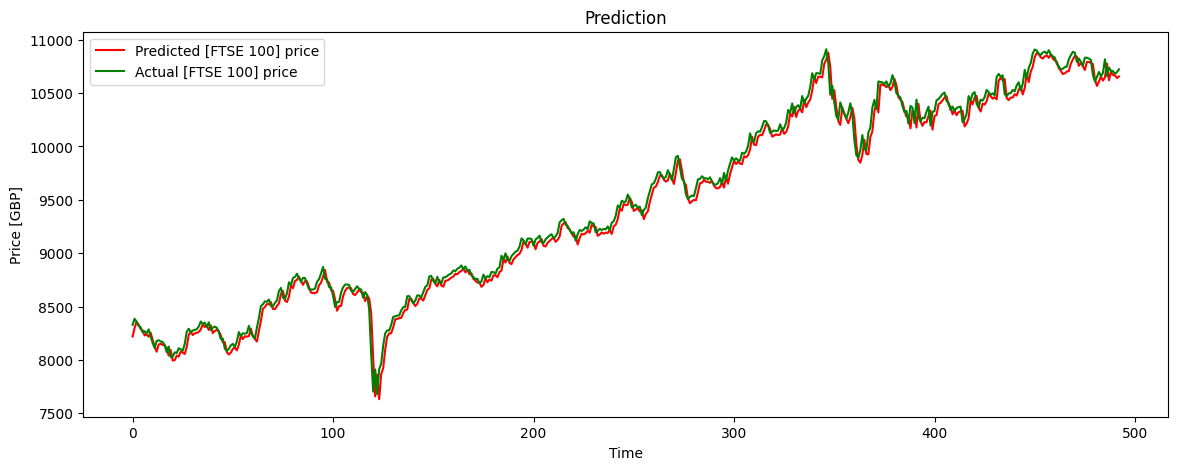

Forecast metrics: {'rmse': 79.7120169046183, 'mae': 60.770487961394096, 'directional_accuracy': 0.44421906693711966, 'rmse_skill_vs_naive': -0.1457949898730284}
prediction is finished


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


Return forecast metrics: {'return_rmse': 0.00871206992304801, 'return_mae': 0.006640264516670029, 'rmse_skill_vs_zero': -0.1655746428553777, 'direction_accuracy': 0.4460285132382892, 'direction_head_accuracy': 0.5539714867617108, 'delta_ic': -0.053584143721277414, 'q10_q90_coverage': 0.9144602851323829}
plotting predictions


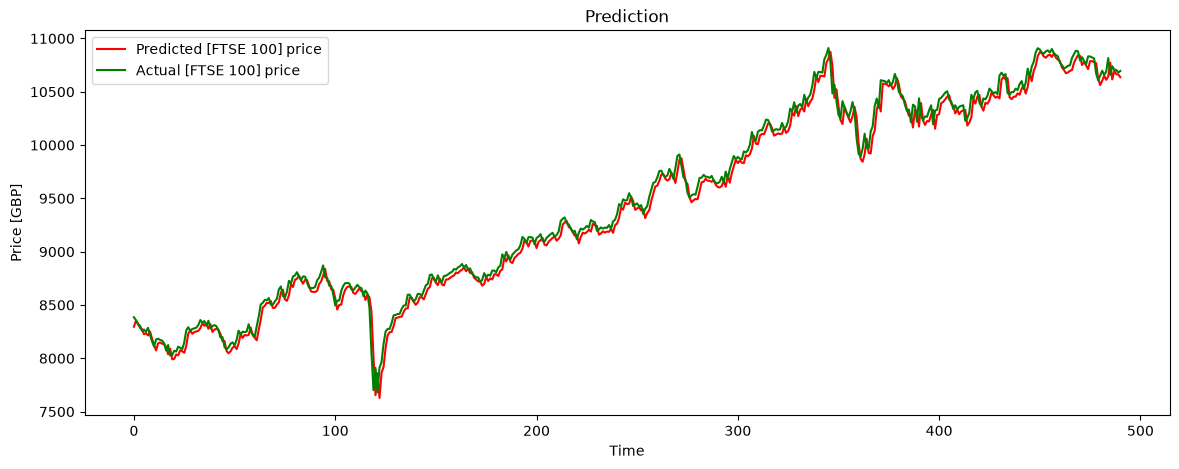

Forecast metrics: {'rmse': 81.33552726840338, 'mae': 62.55029774856063, 'directional_accuracy': 0.4460285132382892, 'rmse_skill_vs_naive': -0.16849522288755825}
prediction is finished


In [4]:
STOCK_TICKER = "^FTSE"
STOCK_START_DATE = pd.to_datetime('2017-01-01')
end_date = datetime.today()
duration = end_date - STOCK_START_DATE
STOCK_VALIDATION_DATE = (STOCK_START_DATE + 0.8 * duration).normalize()

MODEL_VERSION = 'v9'
EPOCHS = 20
BATCH_SIZE = 10
TIME_STEPS = 60
USE_RETURNS = True
VALIDATION_FRACTION = 0.15
SEED = 42
FORECAST_DAYS = 1

TODAY_RUN = datetime.today().strftime("%Y%m%d")
TOKEN = STOCK_TICKER + '_v9_' + TODAY_RUN + '_' + secrets.token_hex(8)
GITHUB_URL = "https://github.com/JordiCorbilla/stock-prediction-deep-neural-learning/raw/master/"

print('Ticker: ' + STOCK_TICKER)
print('Start Date: ' + STOCK_START_DATE.strftime("%Y-%m-%d"))
print('Validation Date: ' + STOCK_VALIDATION_DATE.strftime("%Y-%m-%d"))
print('Model Version: ' + MODEL_VERSION)
print('Target: next-session log return')
print('Test Run Folder: ' + TOKEN)

PROJECT_FOLDER = os.path.join(os.getcwd(), TOKEN)
if not os.path.exists(PROJECT_FOLDER):
    os.makedirs(PROJECT_FOLDER)

stock_prediction = StockPrediction(
    STOCK_TICKER,
    STOCK_START_DATE,
    STOCK_VALIDATION_DATE,
    PROJECT_FOLDER,
    GITHUB_URL,
    EPOCHS,
    TIME_STEPS,
    TOKEN,
    BATCH_SIZE,
)

train_LSTM_network(
    stock_prediction,
    use_returns=USE_RETURNS,
    model_version=MODEL_VERSION,
    forecast_horizon=FORECAST_DAYS,
    trend_window=60,
    validation_fraction=VALIDATION_FRACTION,
    seed=SEED,
)


## Infer the Future Data (Predictions)\n\nThe same `InferenceRunner` used by the existing project loads the saved v9 model and recursively forecasts future log returns, which are converted back into prices for the familiar future-price chart.\n
For v9, the first forecast is left untouched. As the recursive horizon extends without new observed market data, the model contribution decays exponentially toward the training-period mean log return (5-session half-life by default). The CSV keeps both the anchored and unanchored paths for inspection.


2.18.1
Latest Stock Price
10722.2197265625
Latest Date
2026-09-28 00:00:00
v9 return anchor: 0.0024% daily log return, half-life=5 sessions


Model: "return_multitask_lstm_v9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ market_window (InputLayer)    │ (None, 60, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_lstm_1 (LSTM)          │ (None, 60, 128)           │          66,560 │ market_window[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dropout_1 (Dropout)    │ (None, 60, 128)           │               0 │ shared_lstm_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_lstm_2 (LSTM)          │ (None, 64)                │          49,408 │ shared_dropout_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ shared_dropout_2 (Dropout)    │ (None, 64)                │               0 │ shared_lstm_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ median_return (Dense)         │ (None, 1)                 │              65 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lower_distance (Dense)        │ (None, 1)                 │              65 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ upper_distance (Dense)        │ (None, 1)                 │              65 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ q10 (Subtract)                │ (None, 1)                 │               0 │ median_return[0][0],       │
│                               │                           │                 │ lower_distance[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ q90 (Add)                     │ (None, 1)                 │               0 │ median_return[0][0],       │
│                               │                           │                 │ upper_distance[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ direction (Dense)             │ (None, 1)                 │              65 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expected_return (Dense)       │ (None, 1)                 │              65 │ shared_dropout_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ quantiles (Concatenate)       │ (None, 3)                 │               0 │ q10[0][0],                 │
│                               │                           │                 │ median_return[0][0],       │
│                               │                           │                 │ q90[0][0]                  │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 116,293 (454.27 KB)

 Trainable params: 116,293 (454.27 KB)

 Non-trainable params: 0 (0.00 B)

Inference progress: 0/30
Predicted batch size: 1
Inference progress: 3/30
Inference progress: 3/30
Inference progress: 6/30
Inference progress: 6/30
Inference progress: 9/30
Inference progress: 9/30
Inference progress: 12/30
Inference progress: 12/30
Inference progress: 15/30
Inference progress: 15/30
Inference progress: 18/30
Inference progress: 18/30
Inference progress: 21/30
Inference progress: 21/30
Inference progress: 24/30
Inference progress: 24/30
Inference progress: 27/30
Inference progress: 27/30
Inference progress: 30/30
Sanity check - next day delta: -0.37%


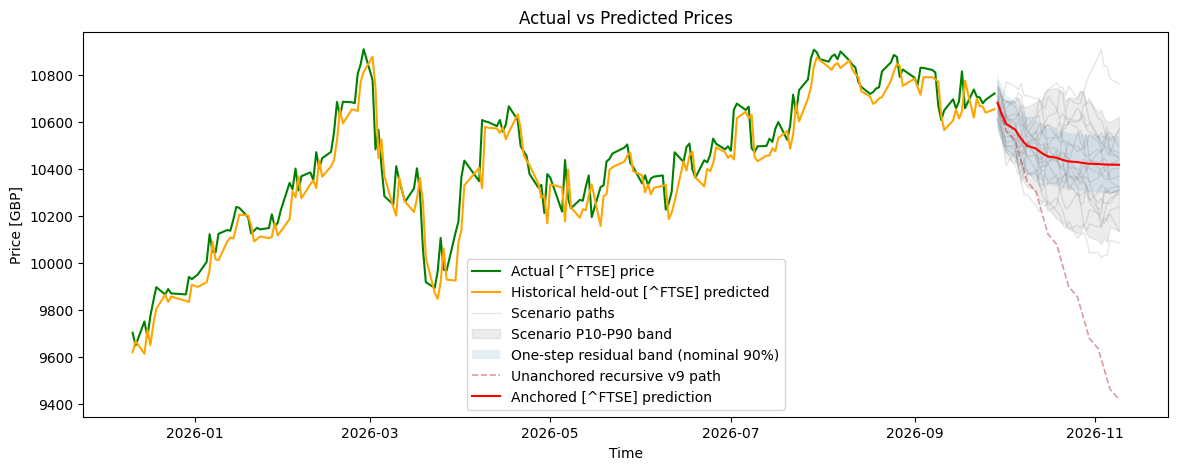

In [6]:
DIRECTION_THRESHOLD = 0.55
MAG_CLIP_PCT = 90
BLEND_ALPHA = 1.0

STOCHASTIC_PATHS = 50
STOCHASTIC_SEED = 42
STOCHASTIC_SIGMA_MULT = 0.6
STOCHASTIC_LOOKBACK = 120

from stock_prediction_deep_learning_inference import InferenceRunner

FORECAST_DAYS = 30
USE_BUSINESS_DAYS = True
PLOT_HISTORY_DAYS = 200
USE_RETURNS = True
USE_DELTAS = False
CLIP_NEGATIVE = True
CONFORMAL_COVERAGE = 0.90
EXCHANGE_CALENDAR = "XLON"
RETURN_ANCHOR_ENABLED = True
RETURN_ANCHOR_HALF_LIFE = 5.0
RETURN_ANCHOR_MODE = "training_mean"

runner = InferenceRunner(
    run_folder=PROJECT_FOLDER,
    ticker=STOCK_TICKER,
    start_date=STOCK_START_DATE,
    validation_date=STOCK_VALIDATION_DATE,
    github_url=GITHUB_URL,
    epochs=EPOCHS,
    time_steps=TIME_STEPS,
    token=TOKEN,
    batch_size=BATCH_SIZE,
    forecast_days=FORECAST_DAYS,
    use_business_days=USE_BUSINESS_DAYS,
    plot_history_days=PLOT_HISTORY_DAYS,
    use_returns=USE_RETURNS,
    use_deltas=USE_DELTAS,
    clip_negative=CLIP_NEGATIVE,
    blend_alpha=BLEND_ALPHA,
    direction_threshold=DIRECTION_THRESHOLD,
    mag_clip_pct=MAG_CLIP_PCT,
    stochastic_paths=STOCHASTIC_PATHS,
    stochastic_seed=STOCHASTIC_SEED,
    stochastic_sigma_mult=STOCHASTIC_SIGMA_MULT,
    stochastic_lookback=STOCHASTIC_LOOKBACK,
    conformal_coverage=CONFORMAL_COVERAGE,
    exchange_calendar=EXCHANGE_CALENDAR,
    return_anchor_enabled=RETURN_ANCHOR_ENABLED,
    return_anchor_half_life=RETURN_ANCHOR_HALF_LIFE,
    return_anchor_mode=RETURN_ANCHOR_MODE,
)
runner.run()


In [7]:
metrics_path = os.path.join(PROJECT_FOLDER, 'return_forecast_metrics.json')
forecast_path = os.path.join(PROJECT_FOLDER, 'forecast_metrics.json')
future_path = os.path.join(PROJECT_FOLDER, 'future_predictions.csv')

with open(metrics_path, encoding='utf-8') as handle:
    return_metrics = json.load(handle)

with open(forecast_path, encoding='utf-8') as handle:
    price_metrics = json.load(handle)

print('v9 held-out return metrics')
display(pd.DataFrame([return_metrics]).round(6))

print('Held-out price reconstruction metrics')
display(pd.DataFrame([price_metrics]).round(6))

future_predictions = pd.read_csv(future_path)
print('First five future predictions')
display(
    future_predictions[
        [
            'Date',
            'Predicted_Price',
            'Predicted_Price_Unanchored',
            'Predicted_Return',
            'Predicted_Return_Raw',
            'Return_Anchor',
            'Return_Model_Weight',
        ]
    ].head()
)

print('Anchor decay across the 30-session horizon')
anchor_rows = sorted(set([0, 5, 10, 20, len(future_predictions) - 1]))
display(
    future_predictions.iloc[anchor_rows][
        [
            'Date',
            'Predicted_Return_Raw',
            'Predicted_Return',
            'Return_Model_Weight',
            'Predicted_Price',
            'Predicted_Price_Unanchored',
        ]
    ]
)


v9 held-out return metrics


,return_rmse,return_mae,rmse_skill_vs_zero,direction_accuracy,direction_head_accuracy,delta_ic,q10_q90_coverage,q10_empirical_cdf,q50_empirical_cdf,q90_empirical_cdf,q10_q90_nominal_coverage
0,0.008545,0.006452,-0.143475,0.444219,0.555781,-0.053871,0.931034,0.010142,0.210953,0.941176,0.8


Held-out price reconstruction metrics


,rmse,mae,directional_accuracy,rmse_skill_vs_naive
0,79.712017,60.770488,0.444219,-0.145795


First five future predictions


,Date,Predicted_Price,Predicted_Price_Unanchored,Predicted_Return,Predicted_Return_Raw,Return_Anchor,Return_Model_Weight
0,2026-09-29,10682.736340,10682.736340,-0.003689,-0.003689,0.000024,1.000000
1,2026-09-30,10648.388175,10643.252034,-0.003220,-0.003703,0.000024,0.870551
2,2026-10-01,10618.155530,10603.257521,-0.002843,-0.003765,0.000024,0.757858
3,2026-10-02,10591.451312,10562.517270,-0.002518,-0.003850,0.000024,0.659754
4,2026-10-05,10567.885936,10520.961960,-0.002227,-0.003942,0.000024,0.574349


Anchor decay across the 30-session horizon


,Date,Predicted_Return_Raw,Predicted_Return,Return_Model_Weight,Predicted_Price,Predicted_Price_Unanchored
0,2026-09-29,-0.003689,-0.003689,1.000000,10682.736340,10682.736340
5,2026-10-06,-0.004032,-0.001963,0.500000,10547.157138,10478.624258
10,2026-10-13,-0.004346,-0.000984,0.250000,10477.139424,10258.797452
20,2026-10-27,-0.004506,-0.000214,0.062500,10427.824993,9811.246740
29,2026-11-09,-0.004527,-0.000043,0.017948,10418.315566,9420.084691
